Génération du graphique corner combiné...

Le graphique corner combiné a été sauvegardé ici : results_bayesian_emcee/corner_posterior_combined_notebook.png


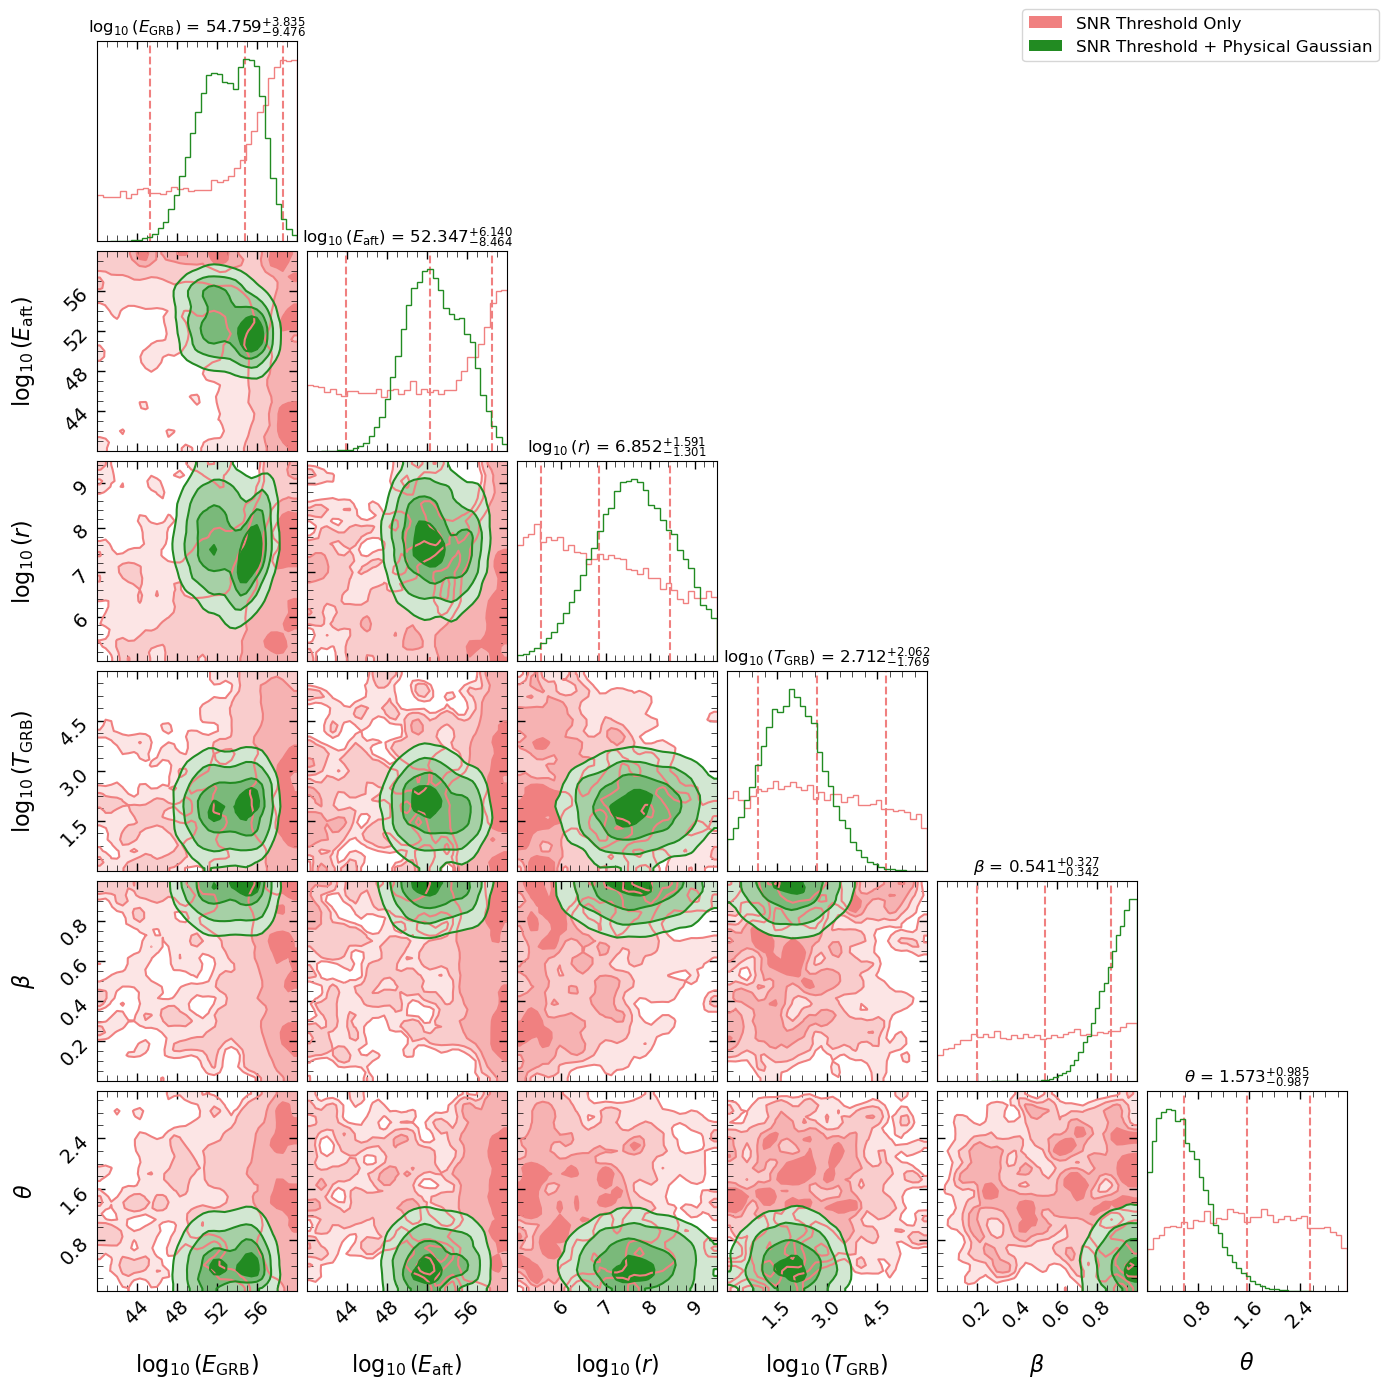

In [1]:
import pandas as pd
import corner
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# --- Configuration ---
# Répertoire de base où les résultats sont sauvegardés
base_outdir = "results_bayesian_emcee"

# Définition des cas, couleurs et labels (identique à votre script)
likelihood_cases = {
    "snr_only": {
        "color": "lightcoral",
        "label": "SNR Threshold Only"
    },
    "snr_and_physical": {
        "color": "forestgreen",
        "label": "SNR Threshold + Physical Gaussian"
    },
}

# Colonnes et labels pour le graphique corner
corner_cols = ["logE_grb", "logE_aft", "logr", "logend_grb", "beta", "theta"]
corner_labels = [
    r"$\log_{10}(E_{\rm GRB})$", r"$\log_{10}(E_{\rm aft})$",
    r"$\log_{10}(r)$", r"$\log_{10}(T_{\rm GRB})$",
    r"$\beta$", r"$\theta$",
]

# --- Chargement des données et création du graphique ---

print("Génération du graphique corner combiné...")

fig_corner_comb = None

# Boucle sur chaque cas pour charger les données et les ajouter au graphique
for case_name, case_info in likelihood_cases.items():
    # Construire le chemin vers le fichier de résultats
    results_file = os.path.join(base_outdir, case_name, "posterior_samples.csv")
    
    if not os.path.exists(results_file):
        print(f"ATTENTION : Le fichier de résultats n'a pas été trouvé pour le cas '{case_name}' à l'emplacement : {results_file}")
        continue

    # Charger les échantillons de la postérieure
    df_post = pd.read_csv(results_file)
    
    color = case_info["color"]
    corner_samples = df_post[corner_cols].to_numpy()
    
    # Correction de l'erreur : Remplacer bins='auto' par un entier, par exemple 35
    bins_value = 35
    
    # Créer le graphique pour le premier cas, puis superposer les autres
    if fig_corner_comb is None:
        fig_corner_comb = corner.corner(
            corner_samples,
            labels=corner_labels,
            bins=bins_value,
            color=color,
            show_titles=True,
            title_fmt=".3f",
            quantiles=[0.16, 0.50, 0.84],
            smooth=1.0,
            plot_datapoints=False,
            fill_contours=True
        )
    else:
        corner.corner(
            corner_samples,
            fig=fig_corner_comb,
            bins=bins_value,
            color=color,
            smooth=1.0,
            plot_datapoints=False,
            fill_contours=True
        )

# --- Ajout de la légende et sauvegarde ---

if fig_corner_comb is not None:
    # Création des éléments de légende
    legend_elements = [mpatches.Patch(facecolor=case_info["color"], label=case_info["label"])
                       for case_info in likelihood_cases.values()]
    
    # Ajout de la légende à la figure
    fig_corner_comb.legend(handles=legend_elements, loc='upper right', fontsize=12, bbox_to_anchor=(1.0, 1.0))
    
    # Sauvegarde de la figure
    output_path = os.path.join(base_outdir, "corner_posterior_combined_notebook.png")
    fig_corner_comb.savefig(output_path, dpi=300, bbox_inches="tight")
    
    print(f"\nLe graphique corner combiné a été sauvegardé ici : {output_path}")
    
    # Afficher le graphique dans le notebook
    plt.show()
else:
    print("Aucune donnée n'a été chargée, le graphique n'a pas pu être généré.")
